<a href="https://colab.research.google.com/github/shrsn17/QuantumChaos/blob/main/BIpartitte_SDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qutip cvxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 31.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import cvxpy as cp
from qutip import *

Z = sigmaz().full()
print(Z)

rho = cp.Variable((2,2), complex=True) # Variable matrix

#Constraints
constraints = [rho >> 0, cp.trace(rho)==1, rho.H == rho]

# Objective
objective = cp.Maximize(cp.real(cp.trace(Z@rho)))

# Problem
prob = cp.Problem(objective, constraints)

# Solve
prob.solve()

# Output
print("Optimal value:", prob.value)
print("Optimal rho:\n", rho.value)



[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Optimal value: 0.9999999997565645
Optimal rho:
 [[1.00000000e+00+0.j 0.00000000e+00+0.j]
 [0.00000000e+00+0.j 1.22462412e-10+0.j]]


Conditional channel min entropy

In [ ]:
!pip install qutip-qip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 9.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
from qutip import *
from qutip.qip.operations import cnot

CNOT = cnot()   # 2-qubit CNOT gate (QuTiP built-in)
choi = to_choi(CNOT) # Its a 16*16 matrix
print(choi)

d=4 # Only then choi state will be 16
def maximally_entangled(d):
    phi = sum(tensor(basis(d, i), basis(d, i)) for i in range(d))
    return phi.unit()   # remove this line if you want unnormalized

Quantum object: dims=[[[2, 2], [2, 2]], [[2, 2], [2, 2]]], shape=(16, 16), type='super', dtype=Dense, isherm=True, superrep='choi'
Qobj data =
[[1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
import numpy as np
import cvxpy as cp
from qutip import *
from qutip.qip.operations import cnot

# Dimensions
dA = 2
dB = 2
dAprime = 2
dBprime = 2

dim_RA = dAprime
dim_RB = dBprime

dim_RA_A = dim_RA * dA      # 2 * 2 = 4
dim_RB_B = dim_RB * dB      # 2 * 2 = 4

U = cnot()
choi_qobj = to_choi(U)  # Qutip returns unnormalised choi
#QuTiP constructs: RA RB A B => A' B' A B ; as RA=A'

# Convert to numpy and ensure tensor product ordering
Gamma = choi_qobj.full()
def reorder_choi(Gamma, dAprime, dBprime, dA, dB):
    G = Gamma.reshape(dAprime, dBprime, dA, dB,
                      dAprime, dBprime, dA, dB)

    G = np.transpose(G, (0, 2, 1, 3,   4, 6, 5, 7))

    return G.reshape(dAprime*dA*dBprime*dB,
                     dAprime*dA*dBprime*dB)

Gamma = reorder_choi(Gamma, dAprime, dBprime, dA, dB) # Unnormalised choi state to calculate channel entropy
print(np.trace(Gamma)) # must be equal to dAprime * dBprime
#Gamma=Gamma/(dAprime * dBprime)# Normalised choi state

#CVXPY variable
M = cp.Variable((dim_RB_B, dim_RB_B), hermitian=True)

I_RA_A  = np.eye(dim_RA_A) #Identity doesnt need reshape. It is basis independent.

# ConstraintS
constraint1 = Gamma << cp.kron(I_RA_A, M) # Γ ≤ I ⊗ M
constraint2 = M >> 0 #M ≥ 0

#Partial trace constraint Tr_B M = (Tr M / |B'|) I_RB
def partial_trace_B_expr(M, dRB, dB):
    M_reshaped = cp.reshape(M, (dRB, dB, dRB, dB))
    result = 0
    for i in range(dB):
        result += M_reshaped[:, i, :, i]
    return result

TrB_M = partial_trace_B_expr(M, dim_RB, dB)
constraint3 = TrB_M == (cp.trace(M) / dBprime) * np.eye(dim_RB)

# Solve SDP
constraints = [constraint1, constraint2, constraint3]

objective = cp.Minimize(cp.real(cp.trace(M)/ dBprime))  # The objective here is to minimize Tr(M)/|B'| = lambda

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, verbose=False)

#Compute entropy
opt_val = prob.value # Returns the optimal value of lambda = Tr(M)/|B'|

S_min = -np.log2(opt_val)

print("Optimal value:", opt_val)
print("Conditional channel min-entropy:", S_min)

(4+0j)
Optimal value: 3.99999999999937
Conditional channel min-entropy: -1.9999999999997726


/usr/local/lib/python3.12/dist-packages/cvxpy/atoms/affine/reshape.py:68: FutureWarning: 
    You didn't specify the order of the reshape expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(reshape_order_warning, FutureWarning)
/usr/local/lib/python3.12/dist-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


Note on subsystem exchange:

Consider (sum) |i> <j|A @ |k> <l|B

=> (sum)|ik> <jl| (order AB)

=> Cikjl = <ik|C|jl> = Cab where a= 2i+k and b=2j+l

Subsystem exchange => let it be (sum) |k> <l|B @ |i> <j|A

=> (sum)|ki> <lj| (order BA)

=> Ckilj = <ki|C|lj> = Cef where e= 2k+i and f=2l+j

Check the relationship between Cab before subsystem exchange and Cef after subsystem exchange for proof.
Refer to image uploaded in drive named as Subsystem exchange for more clarity.

In [17]:
c= np.arange(16).reshape(4,4) # This has elements C(2i+k)(2j+l)
print(c)

c=c.reshape(2,2,2,2)
print(c) # This has C(ik)(jl)

G = np.transpose(c, (1,0,3,2)) # This has C(ki)(lj)

G = G.reshape(4,4) # This has C(2k+i)(2l+j)
print(G)


[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[[[ 0  1]
   [ 2  3]]

  [[ 4  5]
   [ 6  7]]]


 [[[ 8  9]
   [10 11]]

  [[12 13]
   [14 15]]]]
[[ 0  2  1  3]
 [ 8 10  9 11]
 [ 4  6  5  7]
 [12 14 13 15]]


In [ ]:
# Function for Smin SDP
def compute_S_inf(Gamma):
  #CVXPY variable
  M = cp.Variable((dim_RB_B, dim_RB_B), hermitian=True)
  I_RA_A  = np.eye(dim_RA_A) #Identity doesnt need reshape. It is basis independent.

  # ConstraintS
  constraint1 = Gamma << cp.kron(I_RA_A, M) # Γ ≤ I ⊗ M
  constraint2 = M >> 0 #M ≥ 0

  #Partial trace constraint Tr_B M = (Tr M / |B'|) I_RB
  def partial_trace_B_expr(M, dRB, dB):
      M_reshaped = cp.reshape(M, (dRB, dB, dRB, dB))
      result = 0
      for i in range(dB):
          result += M_reshaped[:, i, :, i]
      return result

  TrB_M = partial_trace_B_expr(M, dim_RB, dB)
  constraint3 = TrB_M == (cp.trace(M) / dBprime) * np.eye(dim_RB)

  # Solve SDP
  constraints = [constraint1, constraint2, constraint3]
  objective = cp.Minimize(cp.real(cp.trace(M)/ dBprime))  # The objective here is to minimize Tr(M)/|B'| = lambda
  prob = cp.Problem(objective, constraints)
  prob.solve(solver=cp.SCS, verbose=False)

  #Compute entropy
  opt_val = prob.value # Returns the optimal value of lambda = Tr(M)/|B'|
  S_min = -np.log2(opt_val)
  return S_min

(16, 16)
(16, 16)


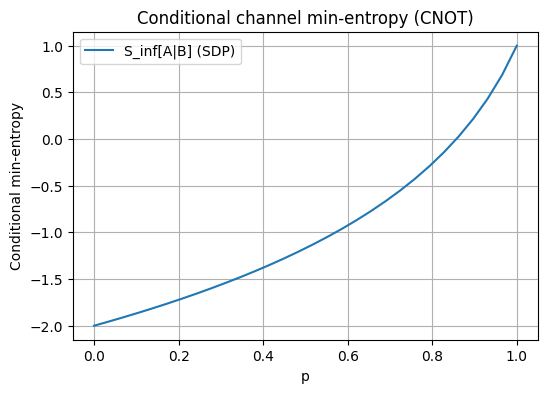

In [ ]:
# Noisy CNOT and checking bounds
import matplotlib.pyplot as plt

# Identity on reference system R ≅ A' => I_R = np.eye(dAprime)
# Maximally mixed state π_A           => pi_A = np.eye(dA) / dA
# Choi OPERATOR (unnormalized)        => Γ_Rπ = I_R ⊗ π_A

Gamma_Rpi = cp.kron(
    np.kron(np.eye(dAprime), np.eye(dA)/dA),   # R^pi on A
    np.outer(np.eye(dB).reshape(-1), np.eye(dB).reshape(-1))  # id on B
)
cnot= choi_qobj.full() #Unormalised choi state
cnot = reorder_choi(cnot, dAprime, dBprime, dA, dB)

print(Gamma_Rpi.shape)
print(cnot.shape)

p_list = np.linspace(0,1,30)
S_vals = []

for p in p_list:
    Np = p*Gamma_Rpi+ (1-p)*cnot
    S_vals.append(compute_S_inf(Np))

plt.figure(figsize=(6,4))
plt.plot(p_list, S_vals, label="S_inf[A|B] (SDP)")
plt.xlabel("p")
plt.ylabel("Conditional min-entropy")
plt.title("Conditional channel min-entropy (CNOT)")
plt.grid()
plt.legend()
plt.show()



Bipartite Tops

In [ ]:
j=jmat(0.5,'x')
print(j)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.  0.5]
 [0.5 0. ]]


Defining the Unitary

In [ ]:

import numpy as np
from qutip import *

j1 = 1   # spin of system A'
j2 = 1 # spin of system B'

k1 = 2.0
k2 = 5.0
alpha1 = 0.35
alpha2 = 0.4

epsilon = 30.2  # coupling strength

# Dimensions
d1prime = int(2*j1 + 1) #dim HA'
d2prime = int(2*j2 + 1) #dim HB'
print('d1',d1prime)

#Angular momentum operators
Jx1, Jy1, Jz1 = jmat(j1, 'x'), jmat(j1, 'y'), jmat(j1, 'z')
Jx2, Jy2, Jz2 = jmat(j2, 'x'), jmat(j2, 'y'), jmat(j2, 'z')
#print(Jx1)

# Identity operators
I1 = qeye(d1prime)
I2 = qeye(d2prime)

# Local unitaries

UA = (-1j * (k1/(2*j1)) * (Jz1 + alpha1)**2).expm() * \
     (-1j * (np.pi/2) * Jy1).expm()

UB = (-1j * (k2/(2*j2)) * (Jz2 + alpha2)**2).expm() * \
     (-1j * (np.pi/2) * Jy2).expm()

# Tensor product
U_local = tensor(UA, UB)

# Interaction Unitary
V12 = tensor(Jz1, Jz2) / np.sqrt(j1 * j2) # Normalize it

U12 = (1j * epsilon * V12).expm()

# Full floquet unitary
U = U12 #* U_local    #Order of tensor prod check

#This U acts from HA'*HB' -> HA*HB

#print("Dimension:", U.shape) # ensure d= d1prime*d2prime
#print((U.dag() * U).tr())  # should equal dimension
#evals = U.eigenenergies() # Eigenvalues should lie within unit circle [-1,1]
#print('evals',evals)
#print(np.abs(np.exp(1j * evals)))
# U.shape = d = d1prime*d2prime


d1 3


Choi and dimension check # Check the re-ordering

In [ ]:
# Choi Matrix of Floquet unitary. Check whether it is imported before.
#Dimensions
d1 = d1prime #dim HA
d2= d2prime #dim HB

dim_RA = d1prime #dim H_RA
dim_RB = d2prime #dim H_RB

dim_RA_A = dim_RA * d1prime
dim_RB_B = dim_RB * d2prime

print('dim RA_A', dim_RA_A)

# CHECK THE RE-ORDER FUNCTION!!!

choi = to_choi(U)
# Convert to numpy
Gamma = choi.full() # Unormalised choi state, #(RA, RB, A, B)
Gamma = reorder_choi(Gamma, d1prime, d2prime, d1, d2) # Takes in (RA, RB, A, B) and outputs (RA,A,RB,B)
print(Gamma.shape)

#Choi op lives in H_RA*HA*H_RB*HB

dim RA_A 9
(81, 81)


SDP

In [ ]:
# SDP

#CVXPY variable
M = cp.Variable((dim_RB_B, dim_RB_B), hermitian=True)

I_RA_A  = np.eye(dim_RA_A) #Identity doesnt need reshape. It is basis independent.

# ConstraintS
constraint1 = Gamma << cp.kron(I_RA_A, M) # Γ ≤ I ⊗ M
constraint2 = M >> 0 #M ≥ 0

#Partial trace constraint Tr_B M = (Tr M / |B'|) I_RB
def partial_trace_B_expr(M, dRB, dB):
    M_reshaped = cp.reshape(M, (dRB, dB, dRB, dB))
    result = 0
    for i in range(dB):
        result += M_reshaped[:, i, :, i]
    return result

TrB_M = partial_trace_B_expr(M, dim_RB, d2)
constraint3 = TrB_M == (cp.trace(M) / d2prime) * np.eye(dim_RB)

# Solve SDP
constraints = [constraint1, constraint2, constraint3]

objective = cp.Minimize(cp.real(cp.trace(M)/ d2prime))  # The objective here is to minimize Tr(M)/|B'| = lambda

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS, verbose=False)

#Compute entropy
opt_val = prob.value # Returns the optimal value of lambda = Tr(M)/|B'|

S_min = -np.log2(opt_val)

print("Optimal value:", opt_val)
print("Conditional channel min-entropy:", S_min)

Optimal value: 7.4339148465381495
Conditional channel min-entropy: -2.894122162617113


---------------- Conditional min entropy vs epsilon------------------------

In [ ]:
def U(epsilon,j1,j2):
  j1 = j1   # spin of system A'
  j2 = j2 # spin of system B'

  k1 = 2.0
  k2 = 5.0
  alpha1 = 0.35
  alpha2 = 0.4

  epsilon = epsilon  # coupling strength

  # Dimensions
  d1prime = int(2*j1 + 1) #dim HA'
  d2prime = int(2*j2 + 1) #dim HB'
  d1 = d1prime #dim HA
  d2= d2prime #dim HB
  dim_RA = d1prime #dim H_RA
  dim_RB = d2prime #dim H_RB
  dim_RA_A = dim_RA * d1prime
  dim_RB_B = dim_RB * d2prime


  #Angular momentum operators
  Jx1, Jy1, Jz1 = jmat(j1, 'x'), jmat(j1, 'y'), jmat(j1, 'z')
  Jx2, Jy2, Jz2 = jmat(j2, 'x'), jmat(j2, 'y'), jmat(j2, 'z')
  #print(Jx1)

  # Identity operators
  I1 = qeye(d1prime)
  I2 = qeye(d2prime)

  # Local unitaries

  UA = (-1j * (k1/(2*j1)) * (Jz1 + alpha1)**2).expm() * \
      (-1j * (np.pi/2) * Jy1).expm()

  UB = (-1j * (k2/(2*j2)) * (Jz2 + alpha2)**2).expm() * \
      (-1j * (np.pi/2) * Jy2).expm()

  # Tensor product
  U_local = tensor(UA, UB)

  # Interaction Unitary
  V12 = tensor(Jz1, Jz2) / np.sqrt(j1 * j2) # Normalize it

  U12 = (1j * epsilon * V12).expm()

  # Full floquet unitary
  U = U12 #* U_local    #Order of tensor prod check

  choi = to_choi(U)
  # Convert to numpy
  Gamma = choi.full() # Unormalised choi state, #(RA, RB, A, B)
  Gamma = reorder_choi(Gamma, d1prime, d2prime, d1, d2) # Takes in (RA, RB, A, B) and outputs (RA,A,RB,B)

  return Gamma

# Returns Un-normalised and re-ordered Choi state.

In [ ]:
#SDP Function

def Smin(Gamma,j1,j2):
  # Dimensions
  d1prime = int(2*j1 + 1) #dim HA'
  d2prime = int(2*j2 + 1) #dim HB'
  d1 = d1prime #dim HA
  d2= d2prime #dim HB
  dim_RA = d1prime #dim H_RA
  dim_RB = d2prime #dim H_RB
  dim_RA_A = dim_RA * d1prime
  dim_RB_B = dim_RB * d2prime

  #CVXPY variable
  M = cp.Variable((dim_RB_B, dim_RB_B), hermitian=True)
  I_RA_A  = np.eye(dim_RA_A) #Identity doesnt need reshape. It is basis independent.
  # ConstraintS
  constraint1 = Gamma << cp.kron(I_RA_A, M) # Γ ≤ I ⊗ M
  constraint2 = M >> 0 #M ≥ 0
  #Partial trace constraint Tr_B M = (Tr M / |B'|) I_RB
  def partial_trace_B_expr(M, dRB, dB):
      M_reshaped = cp.reshape(M, (dRB, dB, dRB, dB))
      result = 0
      for i in range(dB):
          result += M_reshaped[:, i, :, i]
      return result

  TrB_M = partial_trace_B_expr(M, dim_RB, d2)
  constraint3 = TrB_M == (cp.trace(M) / d2prime) * np.eye(dim_RB)

  # Solve SDP
  constraints = [constraint1, constraint2, constraint3]
  objective = cp.Minimize(cp.real(cp.trace(M)/ d2prime))  # The objective here is to minimize Tr(M)/|B'| = lambda
  prob = cp.Problem(objective, constraints)
  prob.solve(solver=cp.SCS, verbose=False)

  #Compute entropy
  opt_val = prob.value # Returns the optimal value of lambda = Tr(M)/|B'|
  S_min = -np.log2(opt_val)
  return S_min


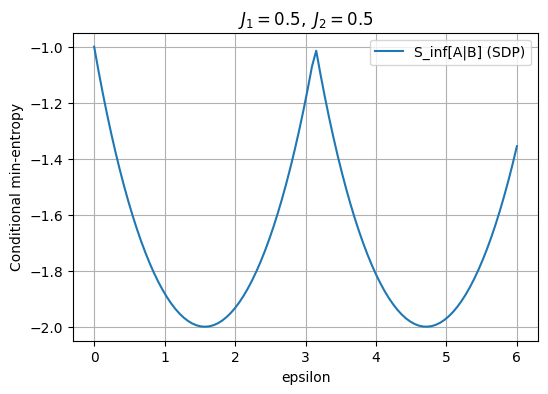

In [ ]:
e= np.linspace(0,6,100)
S_vals = []
j1=0.5
j2=0.5
for eps in e:
    U_eps = U(eps,j1,j2) # Returns Un-normalised and re-ordered Choi state.
    S_vals.append(Smin(U_eps,j1,j2))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(e, S_vals, label="S_min[A|B] (SDP)")
plt.xlabel("epsilon")
plt.ylabel("Conditional min-entropy")
plt.title(rf"$J_1={j1},\; J_2={j2}$")
plt.grid()
plt.legend()
plt.show()

# Check: At e=0, Smin = -log2(d) where d=min(dA,dB) and d=2j+1 (the corresponding j)
# j1=j2=0.5 then at e=0, Smin= -log2(2) = -1

#Try eps=1500

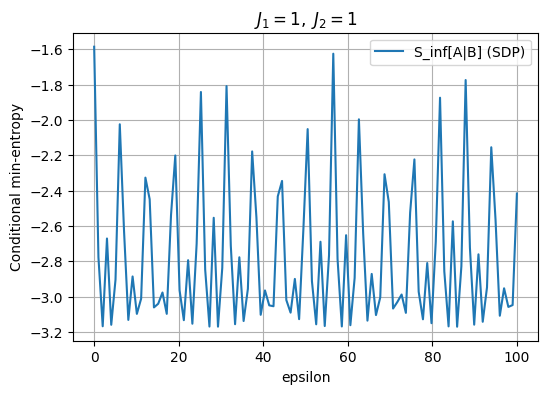

In [ ]:
e= np.linspace(0,100,100)
S_vals = []
j1=1
j2=1
for eps in e:
    U_eps = U(eps,j1,j2) # Returns Un-normalised and re-ordered Choi state.
    S_vals.append(Smin(U_eps,j1,j2))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(e, S_vals, label="S_inf[A|B] (SDP)")
plt.xlabel("epsilon")
plt.ylabel("Conditional min-entropy")
plt.title(rf"$J_1={j1},\; J_2={j2}$")
plt.grid()
plt.legend()
plt.show()


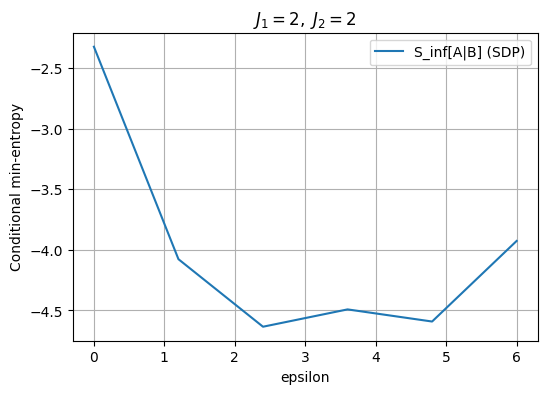

In [ ]:
e= np.linspace(0,6,6)
S_vals = []
j1=2
j2=2
for eps in e:
    U_eps = U(eps,j1,j2) # Returns Un-normalised and re-ordered Choi state.
    S_vals.append(Smin(U_eps,j1,j2))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(e, S_vals, label="S_inf[A|B] (SDP)")
plt.xlabel("epsilon")
plt.ylabel("Conditional min-entropy")
plt.title(rf"$J_1={j1},\; J_2={j2}$")
plt.grid()
plt.legend()
plt.show()

# Ran for 8 hrs no output :(
# Need to optimise

Look at sparse matrix representation

In [ ]:
# CHECK THIS !!!
import numpy as np

# dimensions
d_RA = ...
d_RB = ...
d_A  = ...
d_B  = ...

# choi matrix: shape (d_RA*d_RB, d_A*d_B)
Gamma = ...

# Step 1: reshape into 4 indices
Gamma_tensor = Gamma.reshape(d_RA, d_RB, d_A, d_B)

# Step 2: permute indices
Gamma_reordered = np.transpose(Gamma_tensor, (0, 2, 1, 3))

# Step 3 (optional): flatten back to matrix form
Gamma_final = Gamma_reordered.reshape(d_RA*d_A, d_RB*d_B)